In [110]:
import pandas as pd
import numpy as np
import json, os, sys, joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve
)
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sys.path.append(os.path.join(os.getcwd(), '..'))
from config import TARGET, RANDOM_STATE

print("Imports done.")

Imports done.


In [111]:
# ── Load data ──────────────────────────────────────────────
df = pd.read_csv('../data/processed/features.csv')

with open('../data/processed/selected_features.json') as f:
    selected_features = json.load(f)

selected_features = [c for c in selected_features if c != TARGET]

X = df[selected_features]
y = df[TARGET]

print(f"Original features : {len(selected_features)}")
print(f"Total accounts    : {len(y)}")
print(f"Fraud             : {y.sum()}")
print(f"Legit             : {(y==0).sum()}")

Original features : 45
Total accounts    : 9082
Fraud             : 81
Legit             : 9001


In [112]:
# ── Step 1: Remove known leaker ────────────────────────────
LEAKERS = ['F3912']   # post-fraud flag — must never be used

# Also scan for any other single-feature leakers
print("Scanning for leakers...\n")
X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

auto_leakers = []
for col in selected_features:
    dt   = DecisionTreeClassifier(max_depth=1, random_state=42)
    dt.fit(X_train_tmp[[col]], y_train_tmp)
    prob = dt.predict_proba(X_test_tmp[[col]])[:, 1]
    auc  = roc_auc_score(y_test_tmp, prob)
    if auc >= 0.95:
        auto_leakers.append(col)
        print(f"  Leaker found: {col}  AUC={auc:.4f}")

all_leakers = list(set(LEAKERS + auto_leakers))
print(f"\nAll leakers removed: {all_leakers}")

# Clean feature list
clean_features = [f for f in selected_features if f not in all_leakers]
print(f"Features after leaker removal: {len(clean_features)}")

Scanning for leakers...

  Leaker found: F3912  AUC=1.0000

All leakers removed: ['F3912']
Features after leaker removal: 44


In [113]:
# ── Step 2: Remove features with zero overlap ──────────────
fraud_df = df[y == 1][clean_features]
legit_df = df[y == 0][clean_features]

safe_features = []
removed_zero  = []

for col in clean_features:
    f_min, f_max = fraud_df[col].min(), fraud_df[col].max()
    l_min, l_max = legit_df[col].min(), legit_df[col].max()
    has_overlap  = not (f_max < l_min or l_max < f_min)
    if has_overlap:
        safe_features.append(col)
    else:
        removed_zero.append(col)

print(f"Features with zero overlap removed : {len(removed_zero)}")
print(f"Safe features remaining            : {len(safe_features)}")

Features with zero overlap removed : 0
Safe features remaining            : 44


In [114]:
# ── Step 3: Train/test split ───────────────────────────────
X_safe = df[safe_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_safe, y,
    test_size    = 0.2,
    stratify     = y,
    random_state = RANDOM_STATE
)

print(f"Train → {X_train.shape}   fraud: {y_train.sum()}")
print(f"Test  → {X_test.shape}    fraud: {y_test.sum()}")

Train → (7265, 44)   fraud: 65
Test  → (1817, 44)    fraud: 16


In [115]:
# ── Step 4: Feature selection on training data only ────────
K        = 15
selector = SelectKBest(f_classif, k=min(K, X_train.shape[1]))
selector.fit(X_train, y_train)

mask           = selector.get_support()
final_features = X_train.columns[mask].tolist()

# Re-scan final features for any remaining leakers
print("Final leaker check on selected features:\n")
still_leaking = []
for col in final_features:
    dt   = DecisionTreeClassifier(max_depth=1, random_state=42)
    dt.fit(X_train[[col]], y_train)
    prob = dt.predict_proba(X_test[[col]])[:, 1]
    auc  = roc_auc_score(y_test, prob)
    if auc >= 0.95:
        still_leaking.append(col)
        print(f"  Still leaking: {col}  AUC={auc:.4f}")

final_features = [f for f in final_features if f not in still_leaking]
print(f"\nFinal clean features: {len(final_features)}")
print(final_features)

X_train_sel = X_train[final_features].values
X_test_sel  = X_test[final_features].values

Final leaker check on selected features:


Final clean features: 15
['F159', 'F162', 'F267', 'F270', 'F886', 'F2285', 'F2578', 'F2779', 'F3226', 'F3228', 'F3229', 'F3231', 'F3337', 'F3339', 'F3908']


In [116]:
# ── Step 5: Scale ──────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)

os.makedirs('../models', exist_ok=True)
joblib.dump(scaler,         '../models/scaler.pkl')
joblib.dump(final_features, '../models/feature_names.pkl')
print("Scaled. No SMOTE — using class_weight instead.")

Scaled. No SMOTE — using class_weight instead.


In [117]:
# ── Step 6: Define models ──────────────────────────────────
fraud_count = int(y_train.sum())
legit_count = int((y_train == 0).sum())
ratio       = legit_count / fraud_count
print(f"Imbalance ratio: {ratio:.1f} : 1")

models = {
    "Logistic Regression": LogisticRegression(
        C            = 0.01,
        class_weight = 'balanced',
        max_iter     = 1000,
        solver       = 'lbfgs',
        random_state = RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators      = 100,
        max_depth         = 3,
        min_samples_split = 30,
        min_samples_leaf  = 15,
        max_features      = 'sqrt',
        class_weight      = 'balanced_subsample',
        random_state      = RANDOM_STATE,
        n_jobs            = -1
    ),
    "XGBoost": XGBClassifier(
        n_estimators      = 50,
        max_depth         = 2,
        learning_rate     = 0.05,
        subsample         = 0.7,
        colsample_bytree  = 0.7,
        reg_alpha         = 10.0,
        reg_lambda        = 20.0,
        min_child_weight  = 20,
        gamma             = 10.0,
        scale_pos_weight  = ratio,
        use_label_encoder = False,
        eval_metric       = 'aucpr',
        random_state      = RANDOM_STATE
    ),
    "LightGBM": LGBMClassifier(
        n_estimators      = 50,
        max_depth         = 2,
        num_leaves        = 4,
        learning_rate     = 0.05,
        subsample         = 0.7,
        colsample_bytree  = 0.7,
        reg_alpha         = 10.0,
        reg_lambda        = 20.0,
        min_child_samples = 30,
        class_weight      = 'balanced',
        random_state      = RANDOM_STATE,
        verbose           = -1
    )
}

Imbalance ratio: 110.8 : 1


In [118]:
# ── Step 7: Cross-validation ───────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-fold stratified CV\n")
print(f"{'Model':<22} {'ROC mean':>9} {'±':>7}  {'PR mean':>8} {'±':>7}")
print("-" * 60)

cv_pr = {}
for name, model in models.items():
    res = cross_validate(
        clone(model), X_train_scaled, y_train,
        cv      = cv,
        scoring = ['roc_auc', 'average_precision'],
        n_jobs  = -1
    )
    roc = res['test_roc_auc']
    pr  = res['test_average_precision']
    cv_pr[name] = pr.mean()
    print(f"{name:<22} {roc.mean():.4f}   ±{roc.std():.4f}   "
          f"{pr.mean():.4f}  ±{pr.std():.4f}")

5-fold stratified CV

Model                   ROC mean       ±   PR mean       ±
------------------------------------------------------------
Logistic Regression    0.8245   ±0.0550   0.1384  ±0.0686
Random Forest          0.8555   ±0.0429   0.1396  ±0.0787
XGBoost                0.8348   ±0.0463   0.1146  ±0.0917
LightGBM               0.8434   ±0.0461   0.0848  ±0.0398


In [119]:
# ── Step 8: Train on full training set ─────────────────────
trained = {}
for name, model in models.items():
    m = clone(model)
    m.fit(X_train_scaled, y_train)
    trained[name] = m
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Random Forest
Trained: XGBoost
Trained: LightGBM


In [120]:
# ── Step 9: Tune threshold on training predictions ─────────
best_cv_name  = max(cv_pr, key=cv_pr.get)
best_cv_model = trained[best_cv_name]
y_tr_prob     = best_cv_model.predict_proba(X_train_scaled)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, y_tr_prob)

best_thresh = 0.5
best_f1     = 0.0
for p, r, t in zip(prec[:-1], rec[:-1], thr):
    if r >= 0.3 and p >= 0.05:
        f1 = 2 * p * r / (p + r + 1e-9)
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = float(t)

print(f"Best model (CV)  : {best_cv_name}")
print(f"Best threshold   : {best_thresh:.4f}")
print(f"Best F1 on train : {best_f1:.4f}")

Best model (CV)  : Random Forest
Best threshold   : 0.7020
Best F1 on train : 0.2143


In [121]:
# ── Step 10: Final test set evaluation ─────────────────────
print(f"\nFinal test results  (threshold = {best_thresh:.2f})\n")
print(f"{'Model':<22} {'ROC':>7} {'PR':>7} "
      f"{'TP':>4} {'FP':>5} {'FN':>4} {'TN':>6}")
print("-" * 62)

final_results = []
for name, model in trained.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_prob >= best_thresh).astype(int)

    roc            = roc_auc_score(y_test, y_prob)
    pr             = average_precision_score(y_test, y_prob)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    final_results.append({
        "Model"  : name,
        "AUC-ROC": round(roc, 4),
        "AUC-PR" : round(pr,  4),
        "TP": int(tp), "FP": int(fp),
        "FN": int(fn), "TN": int(tn)
    })
    print(f"{name:<22} {roc:.4f} {pr:.4f} "
          f"{tp:>4} {fp:>5} {fn:>4} {tn:>6}")

results_df = pd.DataFrame(final_results)


Final test results  (threshold = 0.70)

Model                      ROC      PR   TP    FP   FN     TN
--------------------------------------------------------------
Logistic Regression    0.8354 0.1142   10   103    6   1698
Random Forest          0.8731 0.2203    7    52    9   1749
XGBoost                0.8901 0.1847   10   138    6   1663
LightGBM               0.8812 0.1753   10   154    6   1647



Best model : Random Forest
Threshold  : 0.7020
TP  : 7   fraud correctly caught
FP  : 52   legit wrongly flagged
FN  : 9   fraud missed
TN  : 1749   legit correctly cleared

              precision    recall  f1-score   support

       Legit       0.99      0.97      0.98      1801
  Suspicious       0.12      0.44      0.19        16

    accuracy                           0.97      1817
   macro avg       0.56      0.70      0.58      1817
weighted avg       0.99      0.97      0.98      1817



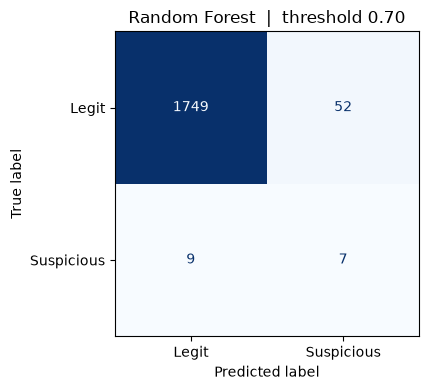

In [122]:
# ── Step 11: Confusion matrix of best model ────────────────
best_name  = results_df.loc[results_df["AUC-PR"].idxmax(), "Model"]
best_model = trained[best_name]

y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred_best = (y_prob_best >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

print(f"\nBest model : {best_name}")
print(f"Threshold  : {best_thresh:.4f}")
print(f"TP  : {tp}   fraud correctly caught")
print(f"FP  : {fp}   legit wrongly flagged")
print(f"FN  : {fn}   fraud missed")
print(f"TN  : {tn}   legit correctly cleared\n")

print(classification_report(
    y_test, y_pred_best,
    target_names=["Legit", "Suspicious"]
))

cm   = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=["Legit","Suspicious"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.title(f"{best_name}  |  threshold {best_thresh:.2f}")
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png')
plt.show()

In [123]:
# ── Step 12: Save all artifacts ────────────────────────────
joblib.dump(best_model,     '../models/best_model.pkl')
joblib.dump(X_test_scaled,  '../models/X_test.pkl')
joblib.dump(y_test,         '../models/y_test.pkl')
joblib.dump(final_features, '../models/feature_names.pkl')
joblib.dump(best_thresh,    '../models/threshold.pkl')
joblib.dump(results_df,     '../models/results_df.pkl')

print(f"Saved : {best_name}")
print(f"Features used    : {len(final_features)}")
print(f"Leakers removed  : {all_leakers}")
print(f"Threshold        : {best_thresh:.4f}")

Saved : Random Forest
Features used    : 15
Leakers removed  : ['F3912']
Threshold        : 0.7020
